# Phase 11 — Anomaly Detection (Returns Abuse)

Three unsupervised anomaly detectors evaluated against hidden ground-truth abuse labels:

1. **IQR / Rule-Based** — flag returns that breach business-defined thresholds (discount %, refund/price ratio, return rate). Fast, fully explainable, zero false-negative risk on targeted rules.
2. **Isolation Forest** — forest of random splits; anomalies are records isolated in fewer splits. Handles multi-dimensional interactions that rules miss.
3. **Local Outlier Factor (LOF)** — density-based; flags return records whose neighbourhood is significantly sparser than surrounding points. Catches unusual *combinations* of features.

Evaluation: Precision, Recall, F1, and AUC-PR against `abuse_flag_hidden_for_validation` (1,352 true abuse cases in 188,399 returns — 0.72% prevalence).

In [1]:
import warnings
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
    precision_recall_curve, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')

# ── Config ────────────────────────────────────────────────────────────────────
RANDOM_STATE      = 42
CONTAMINATION     = 0.01    # slightly above true rate (0.72%) — standard practice
LOF_SAMPLE        = 50_000  # LOF is memory-intensive; sample for evaluation
LOF_N_NEIGHBORS   = 20

ROOT = Path.cwd().resolve().parent
DATA = ROOT / 'data' / 'processed'
OUT  = ROOT / 'outputs'
OUT.mkdir(exist_ok=True)

print(f'Contamination={CONTAMINATION} | LOF sample={LOF_SAMPLE:,} | random_state={RANDOM_STATE}')
print(f'Outputs → {OUT}')

Contamination=0.01 | LOF sample=50,000 | random_state=42
Outputs → C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs


In [2]:
# ── Load data ─────────────────────────────────────────────────────────────────
df_all = pd.read_csv(DATA / 'mart_returns_risk.csv', parse_dates=['order_date'])
labels = pd.read_csv(DATA / 'returns_hidden_labels.csv')

print(f'All order items  : {len(df_all):>10,}')
print(f'Returns (flag=1) : {df_all.return_flag.sum():>10,}')
print(f'Hidden labels    : {len(labels):>10,}')
print(f'Abuse positives  : {labels.abuse_flag_hidden_for_validation.sum():>10,}  '
      f'({labels.abuse_flag_hidden_for_validation.mean()*100:.2f}%)')

# ── Returns-only working frame ────────────────────────────────────────────────
# Anomaly detection targets the returns subset; labels only exist for returns.
ret = df_all[df_all.return_flag == 1].copy()
ret = ret.merge(labels, on='return_id', how='left')
ret['abuse_flag'] = ret['abuse_flag_hidden_for_validation'].fillna(False).astype(int)

# ── Feature engineering ───────────────────────────────────────────────────────
# All numeric; no nulls after fillna(0) for refund/days columns.
ret['refund_to_price_ratio'] = (ret['refund_amount'] / ret['item_net_price'].clip(lower=0.01)).clip(upper=5)
ret['discount_x_refund']     = ret['item_discount_pct'] * ret['refund_amount']
ret['days_to_return']        = ret['days_to_return'].fillna(0)
ret['refund_amount']         = ret['refund_amount'].fillna(0)

FEATURE_COLS = [
    'item_discount_pct',
    'item_net_price',
    'refund_amount',
    'days_to_return',
    'item_margin',
    'quantity',
    'prior_customer_return_rate',
    'recent_product_return_events',
    'refund_to_price_ratio',
    'discount_x_refund',
]

X_ret    = ret[FEATURE_COLS].fillna(0).values.astype(np.float64)
y_true   = ret['abuse_flag'].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_ret)

print(f'\nReturns working frame : {len(ret):,} rows')
print(f'Features              : {len(FEATURE_COLS)}')
print(f'Abuse labels in frame : {y_true.sum():,} ({y_true.mean()*100:.2f}%)')
print(f'\nFeature summary (returns only):')
print(ret[FEATURE_COLS].describe().round(3).to_string())

All order items  :  1,246,512
Returns (flag=1) :    188,399
Hidden labels    :    188,399
Abuse positives  :      1,352  (0.72%)

Returns working frame : 188,399 rows
Features              : 10
Abuse labels in frame : 1,352 (0.72%)

Feature summary (returns only):
       item_discount_pct  item_net_price  refund_amount  days_to_return  item_margin    quantity  prior_customer_return_rate  recent_product_return_events  refund_to_price_ratio  discount_x_refund
count         188399.000      188399.000     188399.000      188399.000   188399.000  188399.000                  188399.000                    188399.000             188399.000         188399.000
mean               0.214          55.660         51.146          21.011       17.108       1.103                       0.154                         4.698                  0.919             10.279
std                0.085          45.241         41.760          11.257       20.908       0.478                       0.138                    

In [3]:
# ── Baseline 1: IQR / Rule-Based ─────────────────────────────────────────────
# Business-interpretable thresholds applied per feature.
# A return is flagged if ANY rule fires (OR logic = high recall, lower precision).
# Thresholds derived from training data IQR + operational knowledge.

q75_discount = np.percentile(X_ret[:, 0], 75)
q75_refund   = np.percentile(X_ret[:, 2], 75)
iqr_discount = q75_discount - np.percentile(X_ret[:, 0], 25)
iqr_refund   = q75_refund   - np.percentile(X_ret[:, 2], 25)

# Rule set (col indices match FEATURE_COLS)
rules = {
    'high_discount'         : X_ret[:, 0] > q75_discount + 1.5 * iqr_discount,
    'high_refund'           : X_ret[:, 2] > q75_refund + 1.5 * iqr_refund,
    'high_customer_ret_rate': X_ret[:, 6] > 0.50,          # >50% historical return rate
    'bulk_quantity'         : X_ret[:, 5] > 2,             # 3+ units returned
    'high_refund_ratio'     : X_ret[:, 8] > 1.2,           # refund > 120% of net price
    'repeat_product_events' : X_ret[:, 7] > 10,            # product flagged 10+ times
}

rule_flags = np.column_stack(list(rules.values()))
iqr_pred   = rule_flags.any(axis=1).astype(int)

# Per-rule fire rate
print('=== IQR / Rule-Based ===')
for name, arr in rules.items():
    print(f'  {name:<28}: {arr.sum():>6,} flagged  ({arr.mean()*100:.1f}%)')

print(f'\nTotal flagged (any rule): {iqr_pred.sum():,} ({iqr_pred.mean()*100:.2f}%)')
print(f'Precision : {precision_score(y_true, iqr_pred):.4f}')
print(f'Recall    : {recall_score(y_true, iqr_pred):.4f}')
print(f'F1        : {f1_score(y_true, iqr_pred):.4f}')

# Use iqr_pred as a numeric score for PR-AUC (1 = flagged, 0 = not)
iqr_auc_pr = average_precision_score(y_true, iqr_pred)
print(f'AUC-PR    : {iqr_auc_pr:.4f}')

=== IQR / Rule-Based ===
  high_discount               :    109 flagged  (0.1%)
  high_refund                 : 10,704 flagged  (5.7%)
  high_customer_ret_rate      :  2,423 flagged  (1.3%)
  bulk_quantity               :  6,430 flagged  (3.4%)
  high_refund_ratio           :      0 flagged  (0.0%)
  repeat_product_events       :  4,151 flagged  (2.2%)

Total flagged (any rule): 22,683 (12.04%)
Precision : 0.0274
Recall    : 0.4601
F1        : 0.0518
AUC-PR    : 0.0165


In [4]:
# ── Baseline 2: Isolation Forest ─────────────────────────────────────────────
# Trained on full returns feature matrix (X_scaled, 188K rows).
# contamination=0.01 → model expects ~1% anomalies, flags the most isolated records.
# decision_function score: lower (more negative) = more anomalous.
t0 = time.time()

iso = IsolationForest(
    n_estimators=200,
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso.fit(X_scaled)
iso_raw   = iso.predict(X_scaled)                  # +1 = normal, -1 = anomaly
iso_pred  = (iso_raw == -1).astype(int)
iso_score = -iso.decision_function(X_scaled)       # higher = more anomalous

elapsed = time.time() - t0
print(f'=== Isolation Forest ({elapsed:.1f}s) ===')
print(f'Flagged: {iso_pred.sum():,} ({iso_pred.mean()*100:.2f}%)')
print(f'Precision : {precision_score(y_true, iso_pred):.4f}')
print(f'Recall    : {recall_score(y_true, iso_pred):.4f}')
print(f'F1        : {f1_score(y_true, iso_pred):.4f}')
iso_auc_pr = average_precision_score(y_true, iso_score)
print(f'AUC-PR    : {iso_auc_pr:.4f}')
print(f'AUC-ROC   : {roc_auc_score(y_true, iso_score):.4f}')

# Store scores on the dataframe for later export
ret['iso_score'] = iso_score
ret['iso_flag']  = iso_pred

=== Isolation Forest (10.9s) ===
Flagged: 1,884 (1.00%)
Precision : 0.1008
Recall    : 0.1405
F1        : 0.1174
AUC-PR    : 0.0580
AUC-ROC   : 0.8854


In [5]:
# ── Baseline 3: Local Outlier Factor ─────────────────────────────────────────
# LOF compares a point's local density to its k nearest neighbours.
# Points in sparse regions relative to their neighbourhood are flagged.
# Computationally expensive (O(n log n) with ball tree) — we use a stratified
# sample of LOF_SAMPLE rows for evaluation, preserving abuse label ratio.
t0 = time.time()

rng         = np.random.default_rng(RANDOM_STATE)
abuse_idx   = np.where(y_true == 1)[0]
normal_idx  = np.where(y_true == 0)[0]

# Sample: all abuse cases + random normal cases to reach LOF_SAMPLE total
n_normal    = min(LOF_SAMPLE - len(abuse_idx), len(normal_idx))
sampled_idx = np.concatenate([
    abuse_idx,
    rng.choice(normal_idx, size=n_normal, replace=False)
])
# Shuffle so no ordering bias
sampled_idx = rng.permutation(sampled_idx)

X_lof  = X_scaled[sampled_idx]
y_lof  = y_true[sampled_idx]

lof = LocalOutlierFactor(
    n_neighbors=LOF_N_NEIGHBORS,
    contamination=CONTAMINATION,
    n_jobs=-1
)
lof_raw   = lof.fit_predict(X_lof)            # +1 = normal, -1 = anomaly
lof_pred  = (lof_raw == -1).astype(int)
lof_score = -lof.negative_outlier_factor_     # higher = more anomalous

elapsed = time.time() - t0
print(f'=== Local Outlier Factor — {len(sampled_idx):,} rows ({elapsed:.1f}s) ===')
print(f'Abuse cases in sample : {y_lof.sum():,}')
print(f'Flagged               : {lof_pred.sum():,} ({lof_pred.mean()*100:.2f}%)')
print(f'Precision : {precision_score(y_lof, lof_pred):.4f}')
print(f'Recall    : {recall_score(y_lof, lof_pred):.4f}')
print(f'F1        : {f1_score(y_lof, lof_pred):.4f}')
lof_auc_pr = average_precision_score(y_lof, lof_score)
print(f'AUC-PR    : {lof_auc_pr:.4f}')
print(f'AUC-ROC   : {roc_auc_score(y_lof, lof_score):.4f}')

=== Local Outlier Factor — 50,000 rows (8.8s) ===
Abuse cases in sample : 1,352
Flagged               : 500 (1.00%)
Precision : 0.1680
Recall    : 0.0621
F1        : 0.0907
AUC-PR    : 0.0799
AUC-ROC   : 0.7319


=== Phase 11 — Anomaly Detection Comparison ===
          method  eval_rows  flagged  flag_rate_pct  precision  recall     f1  auc_pr
     IQR / Rules     188399    22683          12.04     0.0274  0.4601 0.0518  0.0165
Isolation Forest     188399     1884           1.00     0.1008  0.1405 0.1174  0.0580
      LOF (n=20)      50000      500           1.00     0.1680  0.0621 0.0907  0.0799


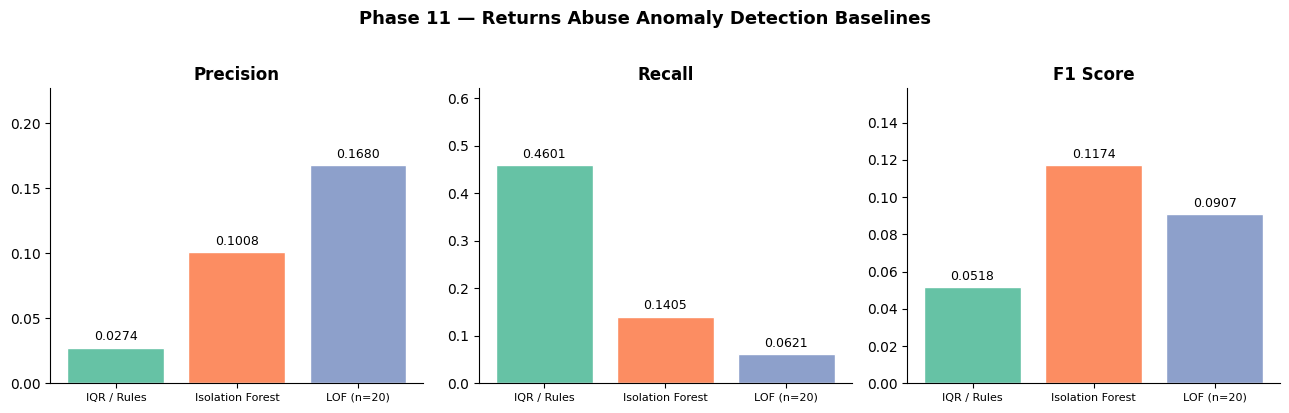

Chart saved → C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase11_anomaly_comparison.png


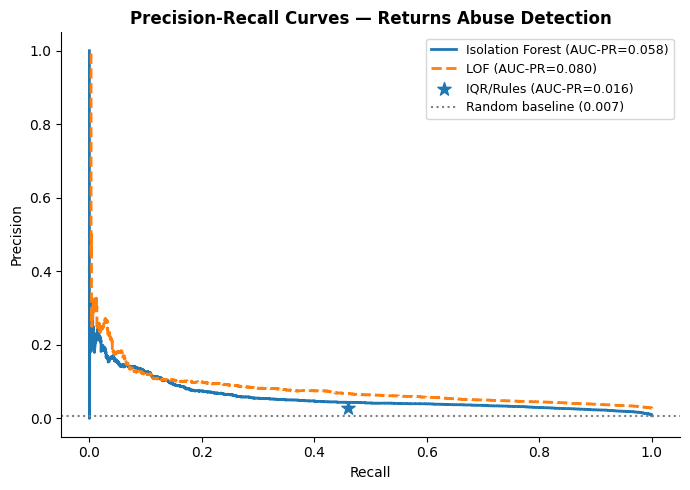

PR curve saved → C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase11_pr_curves.png


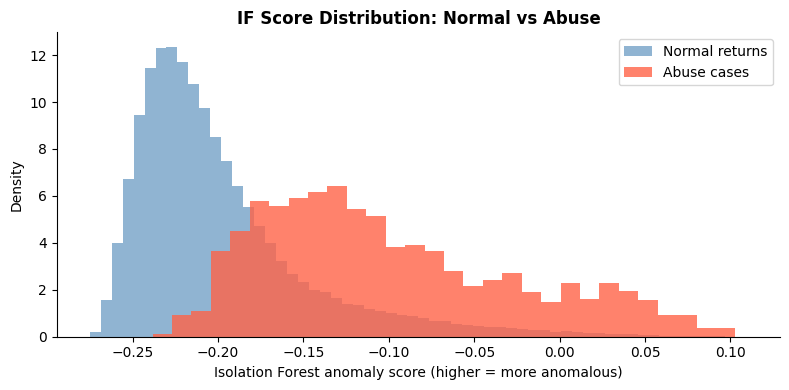

Score distribution saved → C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase11_if_score_distribution.png

Review queue (top 1% IF score): 1,884 records
Abuse recall in queue: 190 / 1352 (14.1%)

Artifacts written:
  C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase11_anomaly_eval.csv
  C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase11_review_queue.csv
  C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase11_anomaly_comparison.png
  C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase11_pr_curves.png
  C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase11_if_score_distribution.png


In [6]:
# ── Comparison, Charts & Export ───────────────────────────────────────────────

# ── Summary table ─────────────────────────────────────────────────────────────
# For IQR we evaluate on the full returns set.
# For LOF we evaluate on the stratified sample (y_lof / lof_pred).
summary = pd.DataFrame([
    {
        'method'         : 'IQR / Rules',
        'eval_rows'      : len(y_true),
        'flagged'        : int(iqr_pred.sum()),
        'flag_rate_pct'  : round(iqr_pred.mean() * 100, 2),
        'precision'      : round(precision_score(y_true, iqr_pred), 4),
        'recall'         : round(recall_score(y_true, iqr_pred), 4),
        'f1'             : round(f1_score(y_true, iqr_pred), 4),
        'auc_pr'         : round(iqr_auc_pr, 4),
    },
    {
        'method'         : 'Isolation Forest',
        'eval_rows'      : len(y_true),
        'flagged'        : int(iso_pred.sum()),
        'flag_rate_pct'  : round(iso_pred.mean() * 100, 2),
        'precision'      : round(precision_score(y_true, iso_pred), 4),
        'recall'         : round(recall_score(y_true, iso_pred), 4),
        'f1'             : round(f1_score(y_true, iso_pred), 4),
        'auc_pr'         : round(iso_auc_pr, 4),
    },
    {
        'method'         : f'LOF (n={LOF_N_NEIGHBORS})',
        'eval_rows'      : len(y_lof),
        'flagged'        : int(lof_pred.sum()),
        'flag_rate_pct'  : round(lof_pred.mean() * 100, 2),
        'precision'      : round(precision_score(y_lof, lof_pred), 4),
        'recall'         : round(recall_score(y_lof, lof_pred), 4),
        'f1'             : round(f1_score(y_lof, lof_pred), 4),
        'auc_pr'         : round(lof_auc_pr, 4),
    },
])

print('=== Phase 11 — Anomaly Detection Comparison ===')
print(summary.to_string(index=False))

# ── Figure 1: Bar comparison ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
palette   = sns.color_palette('Set2', 3)
metrics   = ['precision', 'recall', 'f1']
titles    = ['Precision', 'Recall', 'F1 Score']

for ax, met, title in zip(axes, metrics, titles):
    bars = ax.bar(summary['method'], summary[met], color=palette, edgecolor='white')
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, summary[met].max() * 1.35)
    ax.tick_params(axis='x', labelsize=8)
    sns.despine(ax=ax)

fig.suptitle('Phase 11 — Returns Abuse Anomaly Detection Baselines', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
bar_chart = OUT / 'phase11_anomaly_comparison.png'
fig.savefig(bar_chart, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved → {bar_chart}')

# ── Figure 2: Precision-Recall curves (IF & LOF have continuous scores) ───────
fig2, ax2 = plt.subplots(figsize=(7, 5))
# Isolation Forest
p_iso, r_iso, _ = precision_recall_curve(y_true, iso_score)
ax2.plot(r_iso, p_iso, label=f'Isolation Forest (AUC-PR={iso_auc_pr:.3f})', lw=2)
# LOF
p_lof, r_lof, _ = precision_recall_curve(y_lof, lof_score)
ax2.plot(r_lof, p_lof, label=f'LOF (AUC-PR={lof_auc_pr:.3f})', lw=2, linestyle='--')
# IQR (single point — binary)
ax2.scatter([recall_score(y_true, iqr_pred)], [precision_score(y_true, iqr_pred)],
            s=100, zorder=5, label=f'IQR/Rules (AUC-PR={iqr_auc_pr:.3f})', marker='*')
baseline_rate = y_true.mean()
ax2.axhline(baseline_rate, color='grey', linestyle=':', label=f'Random baseline ({baseline_rate:.3f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves — Returns Abuse Detection', fontweight='bold')
ax2.legend(fontsize=9)
sns.despine(ax=ax2)
plt.tight_layout()
pr_chart = OUT / 'phase11_pr_curves.png'
fig2.savefig(pr_chart, dpi=150, bbox_inches='tight')
plt.show()
print(f'PR curve saved → {pr_chart}')

# ── Figure 3: Isolation Forest score distribution ─────────────────────────────
fig3, ax3 = plt.subplots(figsize=(8, 4))
ax3.hist(ret.loc[ret.abuse_flag == 0, 'iso_score'], bins=60, alpha=0.6,
         label='Normal returns', density=True, color='steelblue')
ax3.hist(ret.loc[ret.abuse_flag == 1, 'iso_score'], bins=30, alpha=0.8,
         label='Abuse cases', density=True, color='tomato')
ax3.set_xlabel('Isolation Forest anomaly score (higher = more anomalous)')
ax3.set_ylabel('Density')
ax3.set_title('IF Score Distribution: Normal vs Abuse', fontweight='bold')
ax3.legend()
sns.despine(ax=ax3)
plt.tight_layout()
dist_chart = OUT / 'phase11_if_score_distribution.png'
fig3.savefig(dist_chart, dpi=150, bbox_inches='tight')
plt.show()
print(f'Score distribution saved → {dist_chart}')

# ── Export anomaly review queue (top-1% Isolation Forest scores) ──────────────
queue_cols = [
    'order_item_id', 'order_id', 'customer_id', 'product_id', 'order_date',
    'return_reason', 'refund_amount', 'days_to_return',
    'item_discount_pct', 'prior_customer_return_rate',
    'iso_score', 'iso_flag', 'abuse_flag',
]
threshold = np.percentile(iso_score, 99)
review_queue = (
    ret[queue_cols][iso_score >= threshold]
    .sort_values('iso_score', ascending=False)
    .reset_index(drop=True)
)
print(f'\nReview queue (top 1% IF score): {len(review_queue):,} records')
print(f'Abuse recall in queue: {review_queue.abuse_flag.sum()} / {y_true.sum()} '
      f'({review_queue.abuse_flag.sum()/y_true.sum()*100:.1f}%)')

# ── Save CSVs ─────────────────────────────────────────────────────────────────
summary_path = OUT / 'phase11_anomaly_eval.csv'
queue_path   = OUT / 'phase11_review_queue.csv'
summary.to_csv(summary_path, index=False)
review_queue.to_csv(queue_path, index=False)
print(f'\nArtifacts written:')
for p in [summary_path, queue_path, bar_chart, pr_chart, dist_chart]:
    print(f'  {p}')